In [80]:
from emukit.test_functions.quadrature import hennig2D
from emukit.core.loop import UserFunctionWrapper

hennig, bounds = hennig2D()
user_function = UserFunctionWrapper(lambda x: hennig.f(x)*10)

lb, ub = bounds[0]

import numpy as np
import GPy

# X = np.array([[-2.],[-0.5], [-0.1]])
X = np.random.randn(10, 2)
Y = user_function.f(X) # inital integrand evaluations at locations X 
gpy_model = GPy.models.GPRegression(X=X, Y=Y, 
                                    kernel=GPy.kern.RBF(input_dim=X.shape[1], 
                                    lengthscale=0.5, 
                                    variance=1.0))

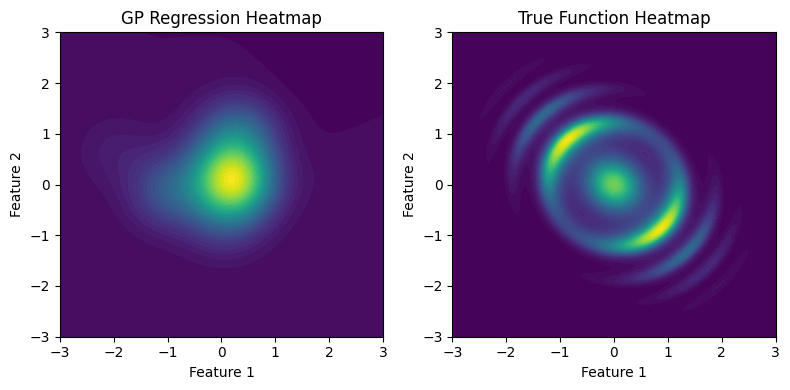

In [81]:
import matplotlib.pyplot as plt
#Generate heatmap plot of the GP model
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
X_grid = np.vstack([X1.ravel(), X2.ravel()]).T
Y_grid, _ = gpy_model.predict(X_grid)
Y_grid = Y_grid.reshape(X1.shape)

cmap = plt.get_cmap('viridis')
scalar = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=Y_grid.min(), vmax=Y_grid.max()))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].contourf(X1, X2, Y_grid, levels=50, cmap=scalar.get_cmap())
# axes[0].scatter(X[:, 0], X[:, 1], c='red', s=10, label='Data Points')
axes[0].set_title('GP Regression Heatmap')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

Y_ref = user_function.f(X_grid)
axes[1].contourf(X1, X2, Y_ref.reshape(X1.shape), levels=50, cmap=scalar.get_cmap())
axes[1].set_title('True Function Heatmap')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
plt.tight_layout()
plt.show()

In [ ]:
from emukit.model_wrappers.gpy_quadrature_wrappers import \
    BaseGaussianProcessGPy, RBFGPy
from emukit.quadrature.kernels import QuadratureRBFLebesgueMeasure
from emukit.quadrature.measures import LebesgueMeasure
from emukit.quadrature.methods import VanillaBayesianQuadrature
from emukit.quadrature.loop import VanillaBayesianQuadratureLoop



emukit_rbf = RBFGPy(gpy_model.kern)
emukit_measure = LebesgueMeasure.from_bounds(bounds=[(lb, ub), (lb, ub)])
emukit_qrbf = QuadratureRBFLebesgueMeasure(emukit_rbf, emukit_measure)
emukit_model = BaseGaussianProcessGPy(kern=emukit_qrbf, gpy_model=gpy_model)
emukit_method = VanillaBayesianQuadrature(base_gp=emukit_model, X=X, Y=Y)
emukit_loop = VanillaBayesianQuadratureLoop(model=emukit_method)

num_iter = 300
emukit_loop.run_loop(user_function, stopping_condition=num_iter)
integral_mean, integral_variance = emukit_loop.model.integrate()

In [ ]:
exp_x = lambda x: user_function.f(x)*x[:, 0]
exp_x_wrapper = UserFunctionWrapper(exp_x)
eval_x, eval_y = emukit_loop.model.X, emukit_loop.model.Y
eval_exp_x = exp_x_wrapper.f(eval_x)


In [ ]:


gpy_model_exp = GPy.models.GPRegression(X=eval_x, Y=eval_exp_x,
                                    kernel=GPy.kern.RBF(input_dim=X.shape[1], 
                                    lengthscale=0.5, 
                                    variance=1.0))
emukit_model_exp = BaseGaussianProcessGPy(kern=emukit_qrbf, gpy_model=gpy_model_exp)
emukit_method_exp = VanillaBayesianQuadrature(base_gp=emukit_model_exp, X=eval_x, Y=eval_exp_x)

In [108]:
emukit_method_exp

In [101]:
list(dir(emukit_method_exp))[-15:]

['compute_warping_params',
 'get_prediction_gradients',
 'integral_bounds',
 'integrate',
 'inverse_transform',
 'measure',
 'optimize',
 'predict',
 'predict_base',
 'predict_base_with_full_covariance',
 'predict_with_full_covariance',
 'reasonable_box_bounds',
 'set_data',
 'symmetrize_matrix',
 'transform']

In [96]:
emukit_method_exp.integrate()

(23.73728151919795, -4.179918218395251)

In [ ]:

exp_x_eval = exp_x_wrapper.f(X)


# exp_x_mean, exp_x_variance = emukit_loop.model.integrate(exp_x_wrapper)

In [ ]:
from emukit.model_wrappers.gpy_quadrature_wrappers import \
    BaseGaussianProcessGPy, RBFGPy
from emukit.quadrature.kernels import QuadratureRBFLebesgueMeasure
from emukit.quadrature.measures import LebesgueMeasure

emukit_rbf = RBFGPy(gpy_model.kern)
emukit_measure = LebesgueMeasure.from_bounds(bounds=[(lb, ub), (lb, ub)])
emukit_qrbf = QuadratureRBFLebesgueMeasure(emukit_rbf, emukit_measure)
emukit_model = BaseGaussianProcessGPy(kern=emukit_qrbf, gpy_model=gpy_model)

In [65]:
print(integral_mean, integral_variance)

3.5442586608439433 0.002559475982609527


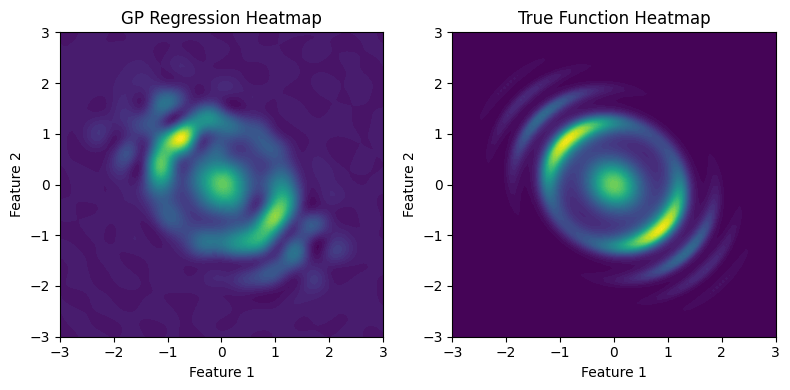

In [64]:
import matplotlib.pyplot as plt
#Generate heatmap plot of the GP model
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
X_grid = np.vstack([X1.ravel(), X2.ravel()]).T
Y_grid, _ = gpy_model.predict(X_grid)
Y_grid = Y_grid.reshape(X1.shape)

cmap = plt.get_cmap('viridis')
scalar = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=Y_grid.min(), vmax=Y_grid.max()))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].contourf(X1, X2, Y_grid, levels=50, cmap=scalar.get_cmap())
# axes[0].scatter(X[:, 0], X[:, 1], c='red', s=10, label='Data Points')
axes[0].set_title('GP Regression Heatmap')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

Y_ref = user_function.f(X_grid)
axes[1].contourf(X1, X2, Y_ref.reshape(X1.shape), levels=50, cmap=scalar.get_cmap())
axes[1].set_title('True Function Heatmap')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
plt.tight_layout()
plt.show()


In [52]:
x = np.linspace(lb, ub, 100)
plt.plot(x, emukit_loop.model.predict(x.reshape(-1, 1))[0], label='GP prediction')
# plt.fill_between(x,
#                  emukit_loop.model.predict(x.reshape(-1, 1))[0] - 2 * np.sqrt(emukit_loop.model.predict(x.reshape(-1, 1))[1]),
#                  emukit_loop.model.predict(x.reshape(-1, 1))[0] + 2 * np.sqrt(emukit_loop.model.predict(x.reshape(-1, 1))[1]),
#                  alpha=0.2, label='95% confidence interval')
plt.title('Vanilla Bayesian Quadrature')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.plot()

IndexError: index 1 is out of bounds for axis 1 with size 1

In [6]:
print("Integral mean:", integral_mean)
print("Integral variance:", integral_variance)

Integral mean: 1.1266874475545916
Integral variance: 0.00022680571472910582


In [ ]:
import GPy
import numpy as np
n_samples = 500
X = np.random.rand(n_samples, 2)  # 10 samples, 2 features
y_fun = lambda x: x[:, 0:1]**2 + np.cos(x[:, 1:2])  # Function to model
Y = y_fun(X) + np.random.randn(n_samples, 1) * 0.1  # Noisy observations
m = GPy.models.GPRegression(X, Y)
m.optimize()

In [12]:
import gpytorch
import torch
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

training_iter = 50
# initialize likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood()
X_train, Y_train = torch.FloatTensor(X), torch.FloatTensor(Y)  # Use the generated data
model = ExactGPModel(X_train, Y_train, likelihood)

model.train()
likelihood.train()

# Use the adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters

# "Loss" for GPs - the marginal log likelihood
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

for i in range(training_iter):
    # Zero gradients from previous iteration
    optimizer.zero_grad()
    # Output from model
    output = model(X_train)
    # Calc loss and backprop gradients
    loss = -mll(output, Y_train).mean()
    print(loss.shape)
    loss.backward()
    print('Iter %d/%d - Loss: %.3f   lengthscale: %.3f   noise: %.3f' % (
        i + 1, training_iter, loss.item(),
        model.covar_module.base_kernel.lengthscale.item(),
        model.likelihood.noise.item()
    ))
    optimizer.step()

torch.Size([])
Iter 1/50 - Loss: 0.761   lengthscale: 0.693   noise: 0.693
torch.Size([])
Iter 2/50 - Loss: 0.723   lengthscale: 0.744   noise: 0.644
torch.Size([])
Iter 3/50 - Loss: 0.684   lengthscale: 0.798   noise: 0.598
torch.Size([])
Iter 4/50 - Loss: 0.645   lengthscale: 0.853   noise: 0.554
torch.Size([])
Iter 5/50 - Loss: 0.605   lengthscale: 0.911   noise: 0.513
torch.Size([])
Iter 6/50 - Loss: 0.564   lengthscale: 0.970   noise: 0.474
torch.Size([])
Iter 7/50 - Loss: 0.523   lengthscale: 1.030   noise: 0.437
torch.Size([])
Iter 8/50 - Loss: 0.481   lengthscale: 1.091   noise: 0.403
torch.Size([])
Iter 9/50 - Loss: 0.438   lengthscale: 1.153   noise: 0.370
torch.Size([])
Iter 10/50 - Loss: 0.395   lengthscale: 1.215   noise: 0.340
torch.Size([])
Iter 11/50 - Loss: 0.351   lengthscale: 1.277   noise: 0.312
torch.Size([])
Iter 12/50 - Loss: 0.307   lengthscale: 1.339   noise: 0.286
torch.Size([])
Iter 13/50 - Loss: 0.262   lengthscale: 1.401   noise: 0.261
torch.Size([])
Iter 1

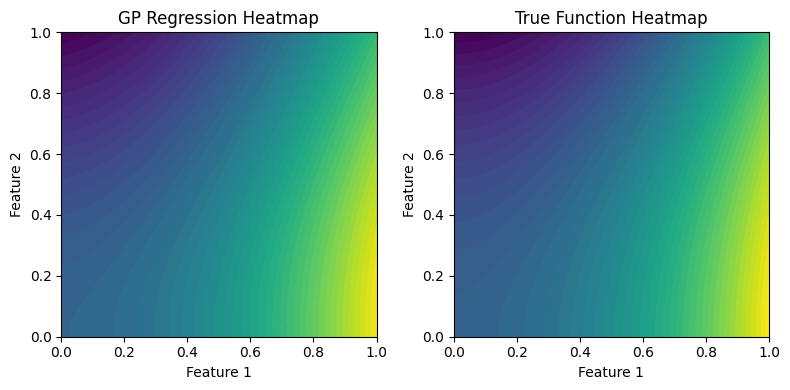

In [24]:
import matplotlib.pyplot as plt
#Generate heatmap plot of the GP model
x1 = np.linspace(0, 1, 100)
x2 = np.linspace(0, 1, 100)
X1, X2 = np.meshgrid(x1, x2)
X_grid = np.vstack([X1.ravel(), X2.ravel()]).T
Y_grid, _ = m.predict(X_grid)
Y_grid = Y_grid.reshape(X1.shape)

cmap = plt.get_cmap('viridis')
scalar = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=Y_grid.min(), vmax=Y_grid.max()))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].contourf(X1, X2, Y_grid, levels=50, cmap=scalar.get_cmap())
# axes[0].scatter(X[:, 0], X[:, 1], c='red', s=10, label='Data Points')
axes[0].set_title('GP Regression Heatmap')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

Y_ref = y_fun(X_grid)
axes[1].contourf(X1, X2, Y_ref.reshape(X1.shape), levels=50, cmap=scalar.get_cmap())
axes[1].set_title('True Function Heatmap')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
plt.tight_layout()
plt.show()


In [ ]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

In [3]:
# True parameter values
alpha, sigma = 1, 1
beta = [1, 2.5]

# Size of dataset
size = 100

# Predictor variable
X1 = np.random.randn(size)
X2 = np.random.randn(size) * 0.2

# Simulate outcome variable
Y = alpha + beta[0] * X1 + beta[1] * X2 + rng.normal(size=size) * sigma

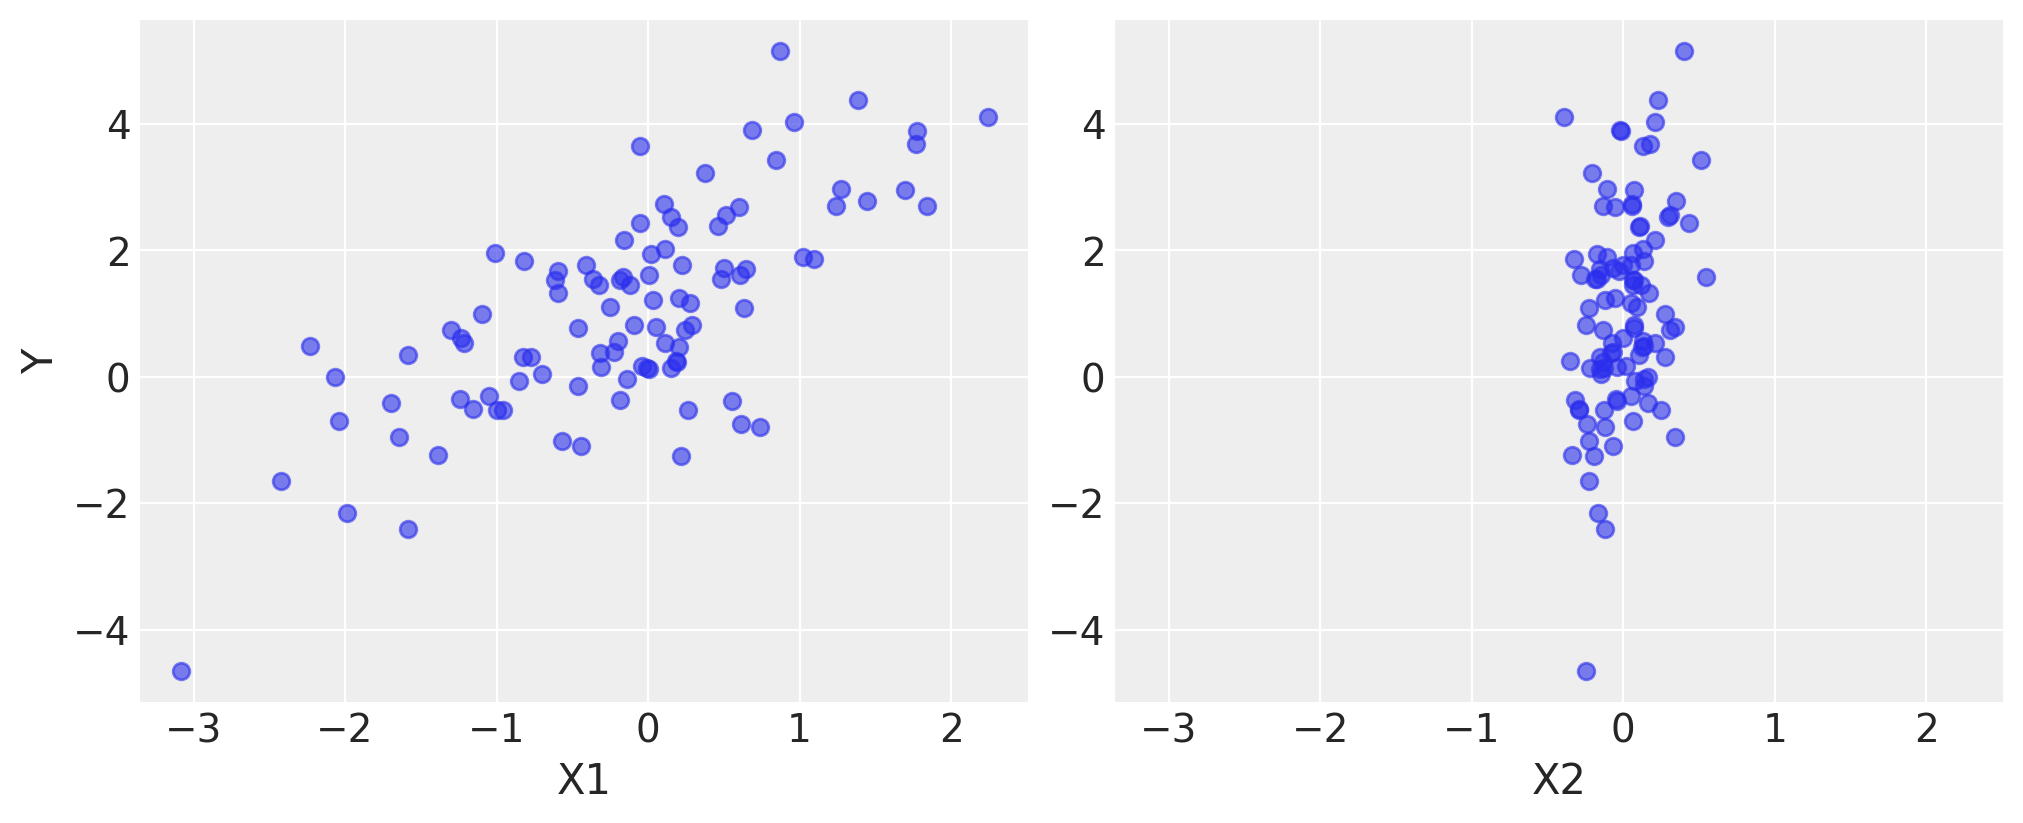

In [4]:
fig, axes = plt.subplots(1, 2, sharex=True, figsize=(10, 4))
axes[0].scatter(X1, Y, alpha=0.6)
axes[1].scatter(X2, Y, alpha=0.6)
axes[0].set_ylabel("Y")
axes[0].set_xlabel("X1")
axes[1].set_xlabel("X2");

In [5]:
import pymc as pm

print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v5.23.0


In [6]:
basic_model = pm.Model()

with basic_model:
    # Priors for unknown model parameters
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta = pm.Normal("beta", mu=0, sigma=10, shape=2)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Expected value of outcome
    mu = alpha + beta[0] * X1 + beta[1] * X2

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=Y)

In [7]:
basic_model = pm.Model()

In [ ]:
with basic_model:
    alpha = pm.Normal('alpha', mu=0, sigma=10)
    beta = pm.Normal('beta', mu=0, sigma=10, shape=2)
    sigma = pm.HalfNormal('sigma', sigma=1)
mu = alpha + beta[0]*X1 + beta[1]*X2
